In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import json

from loguru import logger
from pymatgen.core import Structure

from src.datasets import MaterialsProject

In [3]:
mp = MaterialsProject()
mp.load(force_fetch=True)

2026-03-24 14:16:49.891 | INFO     | src.datasets:_fetch_from_api:1036 - Fetching all stable oxides from API. Using stratified sampling.


Retrieving SummaryDoc documents:   0%|          | 0/10325 [00:00<?, ?it/s]

2026-03-24 14:17:21.234 | INFO     | src.datasets:_fetch_from_api:1059 - Fetched 10325 materials.
Processing materials: 100%|██████████| 1000/1000 [00:00<00:00, 1383.07it/s]
2026-03-24 14:17:22.326 | INFO     | src.datasets:_get_structures:1181 - Reconstructing Pymatgen structures from JSON...
Reconstructing structures: 100%|██████████| 1000/1000 [00:00<00:00, 1223.20it/s]
2026-03-24 14:17:47.772 | INFO     | src.datasets:_add_descriptors:1200 - Computing Periodic SOAP for 1000 structures...
SOAP progress: 100%|██████████| 32/32 [00:07<00:00,  4.53it/s]


SOAP features shape: 1000 x 252


2026-03-24 14:17:57.039 | SUCCESS  | src.datasets:_add_descriptors:1219 - SOAP embeddings added.
2026-03-24 14:17:57.039 | INFO     | src.datasets:_add_descriptors:1223 - Computing Periodic ACSF for 1000 structures...
ACSF progress: 100%|██████████| 32/32 [00:09<00:00,  3.39it/s]
2026-03-24 14:18:08.401 | SUCCESS  | src.datasets:_add_descriptors:1251 - ACSF embeddings averaged and added.
2026-03-24 14:18:08.677 | SUCCESS  | src.datasets:_fetch_from_api:1075 - Dataset saved with 1000 entries.


material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,soap_embedding,acsf_embedding
str,str,f64,f64,f64,bool,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64]
"""mp-18884""","""Na4CrO4""",-5.767007,-1.899032,0.0,true,"""{""@module"": ""pymatgen.core.str…","""Triclinic""","""P-1""",2.860806,5.658837,5.661207,8.568814,81.260051,71.291534,68.302821,241.410075,18,"[27.3872, 78.265352, … 104.12026]","[0.0, 0.0, … 0.0]"
"""mp-6641""","""Ba3SrRu2O9""",-7.134559,-2.432572,0.0,true,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/c""",5.944591,5.986008,5.986008,15.187432,89.134237,89.134237,119.70144,472.489001,30,"[135.05624, 382.012329, … 8.805041]","[0.0, 0.0, … 0.0]"
"""mp-20570""","""HoCoO3""",-7.946193,-2.631197,0.0,true,"""{""@module"": ""pymatgen.core.str…","""Orthorhombic""","""Pnma""",8.876127,5.113198,5.425434,7.333419,90.0,90.0,90.0,203.438721,20,"[120.994232, 360.244125, … 271.783957]","[0.0, 0.0, … 0.0]"
"""mp-1228306""","""Ba6Ca2Ir3RuO18""",-7.08641,-2.407142,0.0,true,"""{""@module"": ""pymatgen.core.str…","""Trigonal""","""P3m1""",6.846546,5.977971,5.977971,14.65349,90.0,90.0,120.000011,453.502056,30,"[158.980766, 451.395794, … 6.547622]","[0.0, 0.0, … 0.0]"
"""mp-1228402""","""Ba2NdTlCu2O7""",-6.319786,-2.180424,0.0,true,"""{""@module"": ""pymatgen.core.str…","""Orthorhombic""","""Pmm2""",7.166137,3.929039,3.948187,12.881668,90.0,90.0,90.0,199.827914,13,"[178.961494, 517.563048, … 448.892678]","[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-1189614""","""BaThO3""",-8.610439,-3.775096,4.047,false,"""{""@module"": ""pymatgen.core.str…","""Orthorhombic""","""Pnma""",7.537982,6.3660955,6.4142298,9.006385,90.0,90.0,90.0,367.763128,20,"[257.896566, 753.065563, … 225.968774]","[0.0, 0.0, … 0.0]"
"""mp-4759""","""ZrTe3O8""",-6.883027,-2.086251,3.7385,false,"""{""@module"": ""pymatgen.core.str…","""Cubic""","""Ia-3""",5.470354,9.828879,9.828943,9.829052,109.472068,109.470251,109.470694,730.977528,48,"[103.31055, 299.31901, … 87.519866]","[0.0, 0.0, … 0.0]"
"""mp-1195057""","""K3Ba3Li2Al4B6O20F""",-7.400843,-3.070059,4.1017,false,"""{""@module"": ""pymatgen.core.str…","""Hexagonal""","""P-62c""",3.194051,8.775476,8.775476,16.447184,90.0,90.0,119.999996,1096.891204,78,"[33.609774, 91.475537, … 78.620029]","[0.0, 0.0, … 0.0]"


In [4]:
mp.df["raw_structure"][0]

'{"@module": "pymatgen.core.structure", "@class": "Structure", "charge": 0, "lattice": {"matrix": [[5.65883536, 0.00368829, 0.00131002], [2.08952352, 5.26147382, 0.00701038], [2.746399959999999, 0.29944804, 8.11123844]], "pbc": [true, true, true], "a": 5.658836713603058, "b": 5.66120697772183, "c": 8.568813856041071, "alpha": 81.26005148550729, "beta": 71.29153446248905, "gamma": 68.30282097170786, "volume": 241.41007546306037}, "properties": {}, "sites": [{"species": [{"element": "Na", "occu": 1}], "abc": [0.94612096, 0.24343142, 0.6011842], "properties": {"magmom": 0.002}, "label": "Na", "xyz": [7.513690683714776, 1.4643210421399508, 4.879294376698806]}, {"species": [{"element": "Na", "occu": 1}], "abc": [0.52118449, 0.26505466, 0.43282519], "properties": {"magmom": 0.001}, "label": "Na", "xyz": [4.6918462517541615, 1.526109088809751, 3.5132892149212642]}, {"species": [{"element": "Na", "occu": 1}], "abc": [0.60718189, 0.73145273, 0.18151684], "properties": {"magmom": 0.002}, "label"

In [5]:
mp.df["acsf_embedding"][0].to_list()

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 5.420320989911776,
 0.43112708813801076,
 1.9762474611675134,
 2.948167616147986,
 0.0,
 0.0,
 0.0,
 0.0,
 5.426882622142643,
 0.24083286613463878,
 1.780833072061767,
 3.494699282056061,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.3407263815575527,
 0.19662814180132349,
 0.4731971965120436,
 0.6656645878176467,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,


In [6]:
duplicate_embeddings = mp.df.join(
    mp.df.group_by("acsf_embedding")
        .len()
        .filter(pl.col("len") > 1),
    on="acsf_embedding"
)

duplicate_embeddings

material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,soap_embedding,acsf_embedding,len
str,str,f64,f64,f64,bool,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],u32


# Plots for investegating

In [7]:
def plot_crystal_system_diversity(df: pl.DataFrame):
    """
    Generates a bar plot showing the distribution of crystal systems.
    """
    logger.info("Generating Crystal System distribution plot...")
    
    crystal_counts = (
        df.group_by("crystal_system")
        .len()
        .sort("len", descending=True)
    )

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Fix: Added x as hue and set legend=False to satisfy new Seaborn syntax
    ax = sns.barplot(
        x=crystal_counts["crystal_system"].to_list(),
        y=crystal_counts["len"].to_list(),
        hue=crystal_counts["crystal_system"].to_list(),
        palette="magma",
        edgecolor=".2",
        legend=False 
    )

    plt.title("Materials Project: Diversity of Crystal Systems", fontsize=15, fontweight='bold')
    plt.xlabel("Crystal System", fontsize=12)
    plt.ylabel("Count (Number of Materials)", fontsize=12)
    plt.xticks(rotation=45)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/crystal_system_diversity.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_volume_distribution(df: pl.DataFrame):
    """
    Generates a KDE plot for Lattice Volume distribution across crystal systems.
    """
    logger.info("Generating Volume Distribution plot...")
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    # Fix: Capture the axes object 'ax'
    ax = sns.kdeplot(
        data=df.to_pandas(), 
        x='volume', 
        hue='crystal_system', 
        fill=True, 
        common_norm=False, 
        alpha=0.4,
        palette="viridis"
    )

    plt.title("Materials Project: Lattice Volume Distribution by Crystal System", fontsize=15, fontweight='bold')
    plt.xlabel("Lattice Volume (Å³)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    
    # Fix: Use sns.move_legend instead of plt.legend()
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Crystal System")
    
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/volume_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    logger.success("Visualization complete.")

2026-03-24 14:18:09.250 | INFO     | __main__:plot_crystal_system_diversity:5 - Generating Crystal System distribution plot...


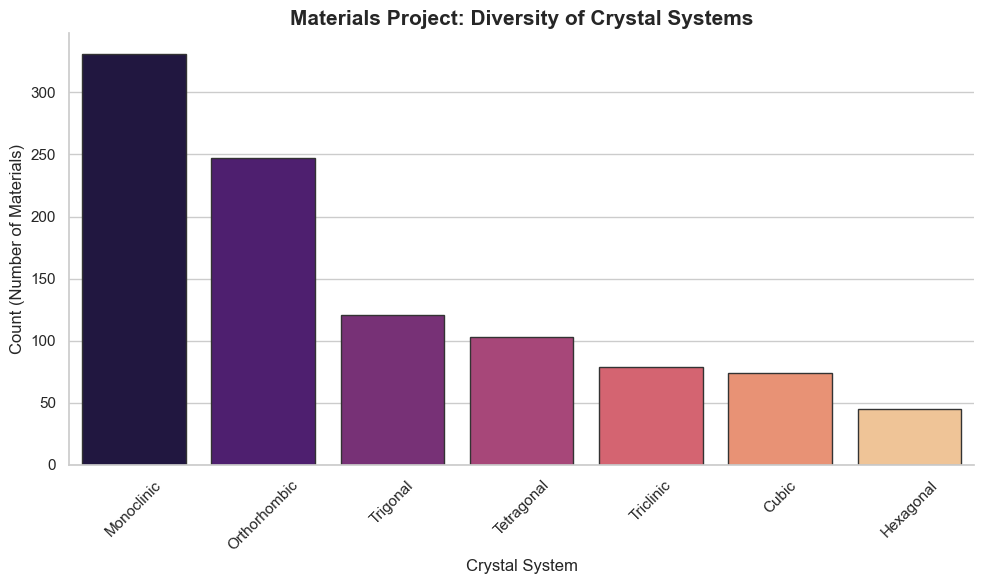

2026-03-24 14:18:09.789 | INFO     | __main__:plot_volume_distribution:40 - Generating Volume Distribution plot...


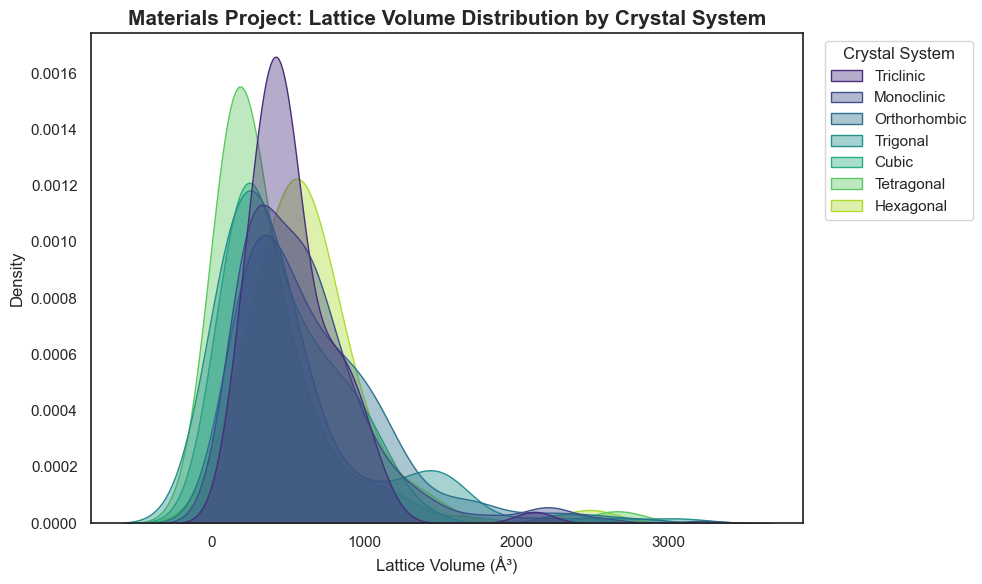

2026-03-24 14:18:10.262 | SUCCESS  | __main__:plot_volume_distribution:66 - Visualization complete.


In [8]:
plot_crystal_system_diversity(mp.df)
plot_volume_distribution(mp.df)

# Show raw structure

In [9]:
mp.df['formula_pretty'][0]

'Na4CrO4'

In [10]:
struct_json = mp.df["raw_structure"][0]
struct = Structure.from_dict(json.loads(struct_json))
print(struct)
struct

Full Formula (Na8 Cr2 O8)
Reduced Formula: Na4CrO4
abc   :   5.658837   5.661207   8.568814
angles:  81.260051  71.291534  68.302821
pbc   :       True       True       True
Sites (18)
  #  SP           a         b         c    magmom
---  ----  --------  --------  --------  --------
  0  Na    0.946121  0.243431  0.601184     0.002
  1  Na    0.521184  0.265055  0.432825     0.001
  2  Na    0.607182  0.731453  0.181517     0.002
  3  Na    0.241412  0.754438  0.987984     0.002
  4  Na    0.758588  0.245562  0.012016     0.002
  5  Na    0.478816  0.734945  0.567175     0.001
  6  Na    0.053879  0.756569  0.398816     0.002
  7  Na    0.392818  0.268547  0.818483     0.002
  8  Cr    0.843307  0.720693  0.756918     1.828
  9  Cr    0.156693  0.279307  0.243082     1.828
 10  O     0.850558  0.846413  0.930539     0.012
 11  O     0.704125  0.973584  0.623323     0.026
 12  O     0.295875  0.026416  0.376677     0.026
 13  O     0.363364  0.470985  0.196676     0.025
 14  O     0.63

Structure Summary
Lattice
    abc : 5.658836713603058 5.66120697772183 8.568813856041071
 angles : 81.26005148550729 71.29153446248905 68.30282097170786
 volume : 241.41007546306037
      A : np.float64(5.65883536) np.float64(0.00368829) np.float64(0.00131002)
      B : np.float64(2.08952352) np.float64(5.26147382) np.float64(0.00701038)
      C : np.float64(2.746399959999999) np.float64(0.29944804) np.float64(8.11123844)
    pbc : True True True
PeriodicSite: Na (7.514, 1.464, 4.879) [0.9461, 0.2434, 0.6012]
PeriodicSite: Na (4.692, 1.526, 3.513) [0.5212, 0.2651, 0.4328]
PeriodicSite: Na (5.463, 3.905, 1.478) [0.6072, 0.7315, 0.1815]
PeriodicSite: Na (5.656, 4.266, 8.019) [0.2414, 0.7544, 0.988]
PeriodicSite: Na (4.839, 1.298, 0.1002) [0.7586, 0.2456, 0.01202]
PeriodicSite: Na (5.803, 4.039, 4.606) [0.4788, 0.7349, 0.5672]
PeriodicSite: Na (2.981, 4.1, 3.24) [0.05388, 0.7566, 0.3988]
PeriodicSite: Na (5.032, 1.659, 6.641) [0.3928, 0.2685, 0.8185]
PeriodicSite: Cr (8.357, 4.022, 6.146)

In [11]:
from chemiscope import show
from pymatgen.io.ase import AseAtomsAdaptor

adaptor = AseAtomsAdaptor()
atoms = adaptor.get_atoms(struct)
#show(atoms, mode="structure")
atoms_super = atoms.repeat([2,2,2])
show([atoms_super], mode="structure")

<StructureWidget(meta={'name': ' '}, structures=[{'size': 144, 'data': 'structure-0'}], properties={'index': {…

# Stratisfied sampling

In [3]:
import numpy as np

In [4]:
mp_head = MaterialsProject(sampling_strategy="head")
df_first = mp_head.load(force_fetch=True)

2026-03-27 09:31:29.394 | INFO     | src.datasets:_fetch_from_api:1034 - Fetching all stable oxides from API. Using head sampling on 'band_gap'.


Retrieving SummaryDoc documents:   0%|          | 0/10325 [00:00<?, ?it/s]

2026-03-27 09:31:44.833 | INFO     | src.datasets:_fetch_from_api:1059 - Fetched 10325 materials.
Processing materials: 100%|██████████| 1000/1000 [00:00<00:00, 8243.13it/s]
2026-03-27 09:31:45.066 | INFO     | src.datasets:_get_structures:1177 - Reconstructing Pymatgen structures from JSON...
Reconstructing structures: 100%|██████████| 1000/1000 [00:00<00:00, 7535.78it/s]
2026-03-27 09:31:57.955 | INFO     | src.datasets:_add_descriptors:1194 - Computing Periodic SOAP for 1000 structures...
SOAP progress: 100%|██████████| 32/32 [00:01<00:00, 17.49it/s]
2026-03-27 09:32:01.292 | SUCCESS  | src.datasets:_add_descriptors:1211 - SOAP embeddings added.
2026-03-27 09:32:01.293 | INFO     | src.datasets:_add_descriptors:1214 - Computing Periodic ACSF for 1000 structures...
ACSF progress: 100%|██████████| 32/32 [00:02<00:00, 14.84it/s]
2026-03-27 09:32:03.797 | SUCCESS  | src.datasets:_add_descriptors:1238 - ACSF embeddings averaged and added.
2026-03-27 09:32:03.943 | SUCCESS  | src.datasets

In [ ]:
mp_strat = MaterialsProject(sampling_strategy="stratified", stratify_on="band_gap")
df_strat = mp_strat.load(force_fetch=True)

2026-03-27 09:32:04.002 | INFO     | src.datasets:_fetch_from_api:1034 - Fetching all stable oxides from API. Using stratified sampling on 'band_gap'.


Retrieving SummaryDoc documents:   0%|          | 0/10325 [00:00<?, ?it/s]

2026-03-27 09:32:17.546 | INFO     | src.datasets:_fetch_from_api:1059 - Fetched 10325 materials.
Processing materials: 100%|██████████| 1000/1000 [00:00<00:00, 4016.29it/s]
2026-03-27 09:32:17.917 | INFO     | src.datasets:_get_structures:1177 - Reconstructing Pymatgen structures from JSON...
Reconstructing structures: 100%|██████████| 1000/1000 [00:00<00:00, 3348.21it/s]
2026-03-27 09:32:30.925 | INFO     | src.datasets:_add_descriptors:1194 - Computing Periodic SOAP for 1000 structures...
SOAP progress: 100%|██████████| 32/32 [00:02<00:00, 11.13it/s]
2026-03-27 09:32:35.340 | SUCCESS  | src.datasets:_add_descriptors:1211 - SOAP embeddings added.
2026-03-27 09:32:35.340 | INFO     | src.datasets:_add_descriptors:1214 - Computing Periodic ACSF for 1000 structures...
ACSF progress: 100%|██████████| 32/32 [00:06<00:00,  5.17it/s]
2026-03-27 09:32:42.409 | SUCCESS  | src.datasets:_add_descriptors:1238 - ACSF embeddings averaged and added.
2026-03-27 09:32:42.735 | SUCCESS  | src.datasets

In [6]:
df_full = mp_head.load(force_fetch=True, limit=None)

2026-03-27 09:32:42.780 | INFO     | src.datasets:_fetch_from_api:1034 - Fetching all stable oxides from API. Using head sampling on 'band_gap'.


Retrieving SummaryDoc documents:   0%|          | 0/10325 [00:00<?, ?it/s]

2026-03-27 09:32:54.873 | INFO     | src.datasets:_fetch_from_api:1059 - Fetched 10325 materials.
Processing materials: 100%|██████████| 10325/10325 [00:02<00:00, 3790.72it/s]
2026-03-27 09:32:57.629 | INFO     | src.datasets:_get_structures:1177 - Reconstructing Pymatgen structures from JSON...
Reconstructing structures: 100%|██████████| 10325/10325 [00:04<00:00, 2496.70it/s]
2026-03-27 09:33:14.460 | INFO     | src.datasets:_add_descriptors:1194 - Computing Periodic SOAP for 10325 structures...
SOAP progress: 100%|██████████| 323/323 [00:29<00:00, 10.91it/s]
2026-03-27 09:33:59.464 | SUCCESS  | src.datasets:_add_descriptors:1211 - SOAP embeddings added.
2026-03-27 09:33:59.464 | INFO     | src.datasets:_add_descriptors:1214 - Computing Periodic ACSF for 10325 structures...
ACSF progress: 100%|██████████| 323/323 [01:07<00:00,  4.82it/s]
2026-03-27 09:35:20.957 | SUCCESS  | src.datasets:_add_descriptors:1238 - ACSF embeddings averaged and added.
2026-03-27 09:35:24.001 | SUCCESS  | sr

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_1411/3420568905.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_pop[column], label="Original Population", color="gray", shade=True, bw_adjust=0.5)


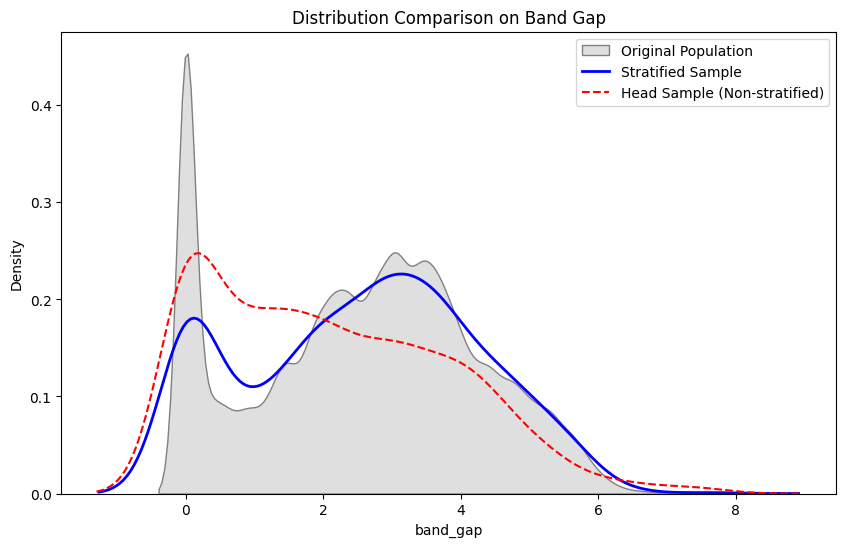

In [8]:
def validate_distributions(df_pop, df_strat, df_head, column="band_gap"):
    plt.figure(figsize=(10, 6))
    
    sns.kdeplot(df_pop[column], label="Original Population", color="gray", shade=True, bw_adjust=0.5)
    
    sns.kdeplot(df_strat[column], label="Stratified Sample", color="blue", linewidth=2)
    
    sns.kdeplot(df_head[column], label="Head Sample (Non-stratified)", color="red", linestyle="--")
    
    plt.title("Distribution Comparison on Band Gap")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()

    plt.savefig(f'figures/materials/sampling/statified_{column}_validation.png', dpi=300)
    plt.show()

validate_distributions(df_full, df_strat, df_first)